In [1]:
import os
import re
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pickle
from tqdm import tqdm
from collections import defaultdict
from scipy.stats import zscore

import utils
import bixby_utils

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
#sub = 'sub-01'
subs = ['sub-01', 'sub-02', 'sub-04', 'sub-05']
#subs = ['sub-06', 'sub-07']

utils.seed_everything(315)

dic = {}

test_images = [f'A_{i}' for i in range(1,19)] + [f'B_{i}' for i in range(1,19)]

data_folder = '/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/'

sessions = ['03', 'study', 'test', 'snap']

folder_path = os.path.join(data_folder, 'afni')

for sub in subs:

    with open(f'{folder_path}/{sub}_roi_vox_all_sessions.pkl', 'rb') as file:
        dic[sub] = pickle.load(file)

    union_mask = dic[sub]['union_mask_2sess']
    print('NSD mask size:', union_mask.shape)
    print('union mask size:', sum(union_mask))
    for ses in sessions:
        dic[sub][ses]['roi'] = dic[sub][ses]['roi'][:, union_mask]
        # z-score each session
        dic[sub][ses]['roi'] = np.nan_to_num(zscore(dic[sub][ses]['roi'], axis=0))
        s = dic[sub][ses]['roi'].shape
        print(f'{ses}: {s}')

NSD mask size: (16946,)
union mask size: 6108
03: (693, 6108)
study: (216, 6108)
test: (216, 6108)
snap: (432, 6108)
NSD mask size: (17175,)
union mask size: 3389
03: (693, 3389)
study: (216, 3389)
test: (216, 3389)
snap: (432, 3389)
NSD mask size: (20397,)
union mask size: 4936
03: (693, 4936)
study: (216, 4936)
test: (216, 4936)
snap: (432, 4936)
NSD mask size: (19907,)
union mask size: 7547
03: (693, 7547)
study: (216, 7547)
test: (216, 7547)
snap: (432, 7547)


In [5]:
for key in dic:
    for ses in sessions:
        print(key, ses)
        print(dic[key][ses]['trial'][0])
        print(dic[key][ses]['roi'].shape)

sub-01 03
notspecial_55933
(693, 6108)
sub-01 study
scene_A_10_study
(216, 6108)
sub-01 test
scene_A_10_test
(216, 6108)
sub-01 snap
scene_A_10_1
(432, 6108)
sub-02 03
notspecial_56418
(693, 3389)
sub-02 study
scene_A_10_study
(216, 3389)
sub-02 test
scene_A_10_test
(216, 3389)
sub-02 snap
scene_A_10_1
(432, 3389)
sub-04 03
notspecial_54389
(693, 4936)
sub-04 study
scene_A_10_study
(216, 4936)
sub-04 test
scene_A_10_test
(216, 4936)
sub-04 snap
scene_A_10_1
(432, 4936)
sub-05 03
notspecial_54389
(693, 7547)
sub-05 study
scene_A_10_study
(216, 7547)
sub-05 test
scene_A_10_test
(216, 7547)
sub-05 snap
scene_A_10_1
(432, 7547)


## Odd/Even Split Check

In [9]:
## Combine study/test/snap

tasks = ['study', 'test', 'snap']

avg_dic = {}

for sub in subs:
    
    avg_dic[sub] = {}
    
    avg_dic[sub]['odd'] = []
    avg_dic[sub]['even'] = []
    
    for task in tasks:
        
        curr_dict = vox_by_run[sub][task]
        
        avg_dic[sub]['odd'].extend([curr_dict[k] for k in ['run-01','run-03','run-05']])
        avg_dic[sub]['even'].extend([curr_dict[k] for k in ['run-02','run-04','run-06']])
    
    avg_dic[sub]['odd'] = np.mean(np.stack(avg_dic[sub]['odd']), axis=0)
    avg_dic[sub]['even'] = np.mean(np.stack(avg_dic[sub]['even']), axis = 0)
    
    
    # Stack A and B vertically to get a [72, 1000] matrix
    combined = np.vstack([avg_dic[sub]['odd'], avg_dic[sub]['even']])
    # np.corrcoef returns a [72, 72] matrix
    full_matrix = np.corrcoef(combined)
    # Extract the top-right [36, 36] block (Correlations of A rows with B rows)
    avg_dic[sub]['correlation'] = full_matrix[:36, 36:]
    
#     corr_matrix = np.empty((len(avg_dic[sub]['odd']), len(avg_dic[sub]['even'])))
#     for i in range(len(avg_dic[sub]['odd'])):
#         for j in range(len(avg_dic[sub]['even'])):
#             corr_matrix[i,j]=np.corrcoef(avg_dic[sub]['odd'][i], avg_dic[sub]['even'][j])[0,1]

NameError: name 'vox_by_run' is not defined

In [8]:
avg_dic[sub]['odd'].shape

AttributeError: 'list' object has no attribute 'shape'

In [12]:
overall = {}
sd = {}

for sub in subs:
    same = []
    competitor = []
    others = []
    overall[sub] = {}
    sd[sub] = {}
    
    overall_score = 0.
    with_pair_score = 0.
    across_pair_score = 0.
    count = 0.
    
    for i, img in enumerate(test_images):
        img_folder = img.split('_')[0]
        img_id = img.split('_')[-1]

        same_idx = i
        competitor_folder= 'A' if img_folder == 'B' else 'B'
        competitor_idx = test_images.index(competitor_folder+'_'+img_id)

        #print('img:', img_folder, img_id, '@ idx', same_idx)
        #print('competitor:', competitor_folder, img_id, '@ idx', competitor_idx)

        curr_arr = avg_dic[sub]['correlation'][i]
        same.append(curr_arr[i])
        competitor.append(curr_arr[competitor_idx])

        indices_to_exclude = np.array([i, competitor_idx])
        # Create a boolean mask indicating elements NOT in the exclusion list
        mask = ~np.isin(np.arange(len(curr_arr)), indices_to_exclude)

        # Use the mask to select the elements
        others.append(curr_arr[mask])
        
        if curr_arr[i] > curr_arr[competitor_idx]:
            with_pair_score += 1
        if curr_arr[i] > max(curr_arr[mask]):
            across_pair_score += 1
        if curr_arr[i] > max(curr_arr[mask]) and curr_arr[i] > curr_arr[competitor_idx]:
            overall_score += 1
        
        count += 1
        
        
    # Look at columns for each evaluation
    for i, img in enumerate(test_images):
        
        img_folder = img.split('_')[0]
        img_id = img.split('_')[-1]

        same_idx = i
        competitor_folder= 'A' if img_folder == 'B' else 'B'
        competitor_idx = test_images.index(competitor_folder+'_'+img_id)

        curr_arr = avg_dic[sub]['correlation'][:,i]

        indices_to_exclude = np.array([i, competitor_idx])
        # Create a boolean mask indicating elements NOT in the exclusion list
        mask = ~np.isin(np.arange(len(curr_arr)), indices_to_exclude)

        if curr_arr[i] > curr_arr[competitor_idx]:
            with_pair_score += 1
        if curr_arr[i] > max(curr_arr[mask]):
            across_pair_score += 1
        if curr_arr[i] > max(curr_arr[mask]) and curr_arr[i] > curr_arr[competitor_idx]:
            overall_score += 1
        
        count += 1
        
    print(sub)
    
    print(count)
    
    print('within item vs. all: ', overall_score/count)
    print('within item vs. within pair: ', with_pair_score/count)
    print('within item vs. across pair: ', across_pair_score/count)

    
    overall[sub]['within_item'] = np.mean(same)
    overall[sub]['within_pair'] = np.mean(competitor)
    overall[sub]['across_pair'] = np.mean(others)
    
    sd [sub]['within_item'] = np.std(same) / np.sqrt(len(same))
    sd [sub]['within_pair'] = np.std(competitor) / np.sqrt(len(competitor))
    sd [sub]['across_pair'] = np.std(others) / np.sqrt(len(others) * len(others[0]))

    print('within_item', np.mean(same))
    print('within_pair', np.mean(competitor))
    print('across_pair', np.mean(others))

sub-01
72.0
within item vs. all:  0.6111111111111112
within item vs. within pair:  0.7777777777777778
within item vs. across pair:  0.7222222222222222
within_item 0.24622915134181833
within_pair 0.16447412723594354
across_pair -0.06820737301990977
sub-02
72.0
within item vs. all:  0.3194444444444444
within item vs. within pair:  0.6111111111111112
within item vs. across pair:  0.375
within_item 0.19368424608272486
within_pair 0.1523699125172845
across_pair -0.0426775719507837
sub-04
72.0
within item vs. all:  0.4444444444444444
within item vs. within pair:  0.6666666666666666
within item vs. across pair:  0.625
within_item 0.21403120346958562
within_pair 0.17079298915077357
across_pair -0.05044128463491768


In [13]:
import pandas as pd
overall_df = pd.DataFrame(overall)
sd_df = pd.DataFrame(sd)

In [14]:
overall_df

,sub-01,sub-02,sub-04
within_item,0.246229,0.193684,0.214031
within_pair,0.164474,0.152370,0.170793
across_pair,-0.068207,-0.042678,-0.050441


In [15]:
sd_df

,sub-01,sub-02,sub-04
within_item,0.016249,0.024975,0.018270
within_pair,0.017020,0.023237,0.019571
across_pair,0.003483,0.003805,0.002935


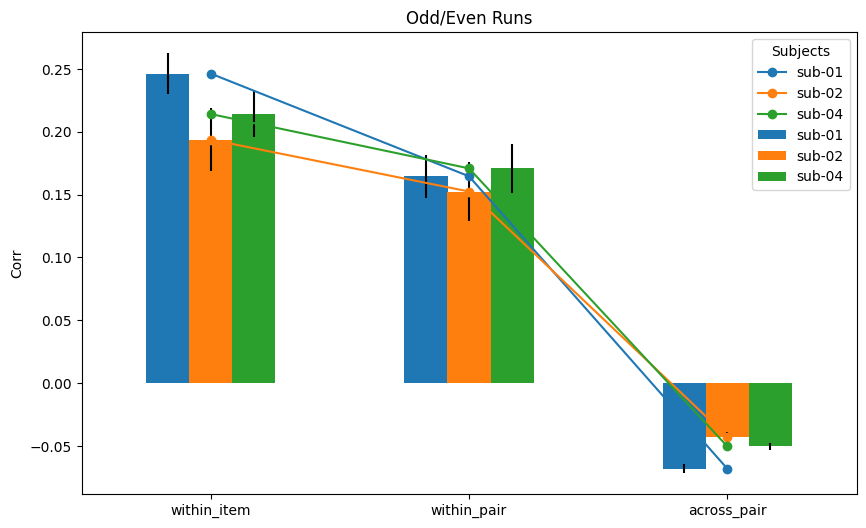

In [16]:
ax = overall_df.plot(kind='bar',  yerr=sd_df, figsize=(10, 6), rot=0) 
overall_df.plot(kind='line', marker='o',  ax=ax, legend=False)
# 3. Customize the plot using Matplotlib methods
ax.set_title('Odd/Even Runs')
#ax.set_xlabel('Types')
ax.set_ylabel('Corr')
ax.legend(title='Subjects') # Customize the legend title


# Display the plot
plt.show()

## Paires averaging and cleaning

In [92]:
subs

['sub-01', 'sub-02', 'sub-04', 'sub-05']

In [93]:
# Loading Snap data
tasks = ['study', 'test', 'snap']

test_data = {}

for sub in subs:
    
    test_data[sub] = {}
    
    for task in tasks:

        sub_dict = dic[sub][task]

        repeat_idx, per_run_repeat_idx = locate_repeat_index_per_run(sub_dict)

        test_data[sub][task] = average_repeats_across_run(sub_dict['roi'], repeat_idx, test_images) # averaging all repeats across run in the sequence of test_images

In [94]:
test_data.keys()

dict_keys(['sub-01', 'sub-02', 'sub-04', 'sub-05'])

In [95]:
test_data[sub].keys()

dict_keys(['study', 'test', 'snap'])

In [96]:

from torchvision import transforms
import imageio.v2 as imageio

resize_transform = transforms.Resize((224, 224))

test_img_tensor = None
img_path = f'/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/afni/loaded_test_imgs.pkl'

# if os.path.exists(img_path):
#     with open(img_path, 'rb') as file:
#         test_img_tensor = pickle.load(file)
#         print('Loading image saved at: ', file)
# else:
for img in test_images:

    root_dir = os.path.join(data_folder, 'stimuli', 'scenes')
    img_list = img.split('_')[0]
    img_id = int(img.split('_')[1])

    image_file = f'{root_dir}/list{img_list}/{img_id:02d}.png'

    print(img_list, img_id)

    if image_file and not os.path.exists(image_file):
        print('Cannot find the image at this path',image_file)
        break

    im = imageio.imread(image_file)
    im = torch.Tensor(im / 255).permute(2,0,1)
    im = resize_transform(im.unsqueeze(0))

    if test_img_tensor is None:
        test_img_tensor = im
    else:
        test_img_tensor = torch.vstack((test_img_tensor, im))

# print(folder_path)
# with open(img_path, 'wb') as file:
#     pickle.dump(test_img_tensor, file)
#     print('image saved at: ', file)

print("testing images", test_img_tensor.shape)

A 1
A 2
A 3
A 4
A 5
A 6
A 7
A 8
A 9
A 10
A 11
A 12
A 13
A 14
A 15
A 16
A 17
A 18
B 1
B 2
B 3
B 4
B 5
B 6
B 7
B 8
B 9
B 10
B 11
B 12
B 13
B 14
B 15
B 16
B 17
B 18
testing images torch.Size([36, 3, 224, 224])


In [97]:
sub = 'sub-05'

In [98]:
test_images_embeddings = torch.Tensor(test_img_tensor)
test_vox = torch.Tensor(np.mean([test_data[sub]['study'], test_data[sub]['test'], test_data[sub]['snap']], axis=0))
test_vox_study = torch.Tensor(test_data[sub]['study'])
test_vox_test = torch.Tensor(test_data[sub]['test'])
test_vox_snap = torch.Tensor(test_data[sub]['snap'])
assert len(test_images_embeddings) == len(test_vox)

### Loading pre-trained subject model

In [99]:
outdir_folder = '/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/'
folder_names = {'sub-01':'sub-01_output_1771911499.2133198',
                'sub-02':'sub-02_output_1771391206.9882252', 
                'sub-04':'sub-04_output_1771391422.1811972',}
folder_names = {'sub-01':'output_sub-01_sub-01_3-session_task-mindeye_1_avgrepeats_unionmask_150epochs_1772602372.517717',
                'sub-02':'output_sub-02_sub-02_3-session_task-mindeye_2_avgrepeats_unionmask_150epochs_1772601956.315377', 
                'sub-04':'output_sub-04_sub-04_3-session_task-mindeye_4_avgrepeats_unionmask_150epochs_1772602765.0265508',
                'sub-05':'output_sub-05_sub-05_3-session_task-mindeye_5_avgrepeats_unionmask_150epochs_1772665013.0029678'}

outdir = os.path.join(outdir_folder, folder_names[sub])

In [100]:
def load_ckpt(tag,load_lr=True,load_optimizer=True,load_epoch=True,strict=True,outdir=outdir,multisubj_loading=False): 
    print(f"\n---loading {outdir}/{tag}.pth ckpt---\n")
    checkpoint = torch.load(outdir+'/last.pth', map_location='cpu')
    state_dict = checkpoint['model_state_dict']
    if multisubj_loading: # remove incompatible ridge layer that will otherwise error
        state_dict.pop('ridge.linears.0.weight',None)
    model.load_state_dict(state_dict, strict=strict)
    if load_epoch:
        globals()["epoch"] = checkpoint['epoch']
        print("Epoch",epoch)
    if load_optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if load_lr:
        lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])
    del checkpoint

In [101]:
import torch.nn as nn
### Multi-GPU config ###
from accelerate import Accelerator, DeepSpeedPlugin

local_rank = os.getenv('RANK')
if local_rank is None: 
    local_rank = 0
else:
    local_rank = int(local_rank)
print("LOCAL RANK ", local_rank)  

data_type = torch.float32 # change depending on your mixed_precision

accelerator = Accelerator(split_batches=False)

device = accelerator.device

LOCAL RANK  0


In [102]:
print("PID of this process =",os.getpid())
device = accelerator.device
print("device:",device)
world_size = accelerator.state.num_processes
distributed = not accelerator.state.distributed_type == 'NO'
num_devices = torch.cuda.device_count()
if num_devices==0 or not distributed: num_devices = 1
num_workers = num_devices
print(accelerator.state)

# set data_type to match your mixed precision (automatically set based on deepspeed config)
if accelerator.mixed_precision == "bf16":
    data_type = torch.bfloat16
elif accelerator.mixed_precision == "fp16":
    data_type = torch.float16
else:
    data_type = torch.float32

print("distributed =",distributed, "num_devices =", num_devices, "local rank =", local_rank, "world size =", world_size, "data_type =", data_type)
print = accelerator.print # only print if local_rank=0

PID of this process = 1522724
device: cuda
Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

distributed = False num_devices = 1 local rank = 0 world size = 1 data_type = torch.float32


In [103]:
from models import PriorNetwork, BrainDiffusionPrior
import utils

## USING OpenCLIP ViT-bigG ###
sys.path.append('generative_models/')
import sgm
from generative_models.sgm.modules.encoders.modules import FrozenOpenCLIPImageEmbedder
# from generative_models.sgm.models.diffusion import DiffusionEngine
# from omegaconf import OmegaConf

In [104]:
try:
    print(clip_img_embedder)
except:
    clip_img_embedder = FrozenOpenCLIPImageEmbedder(
        arch="ViT-bigG-14",
        version="laion2b_s39b_b160k",
        output_tokens=True,
        only_tokens=True,
    )
    clip_img_embedder.to(device)
clip_img_embedder.model.visual.set_grad_checkpointing(True)

clip_seq_dim = 256
clip_emb_dim = 1664

FrozenOpenCLIPImageEmbedder(
  (model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 1664, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (patch_dropout): Identity()
      (ln_pre): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): ModuleList(
          (0-47): 48 x ResidualAttentionBlock(
            (ln_1): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=1664, out_features=1664, bias=True)
            )
            (ls_1): Identity()
            (ln_2): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=1664, out_features=8192, bias=True)
              (gelu): GELU(approximate='none')
              (c_proj): Linear(in_features=8192, out_features=1664, bias=True)
            )
            (ls_2): Identity()


In [105]:
[dic[sub]['study']['roi'].shape[-1]]

[7547]

In [106]:
#num_voxels_list = [dic[sub]['study']['roi'].shape[-1]]
num_voxels_list = [dic[sub]['study']['roi'].shape[-1]]
n_blocks=4
hidden_dim=1024
use_prior=False
clip_scale=1.

model = utils.prepare_model_and_training(
    num_voxels_list=num_voxels_list,
    n_blocks=n_blocks,
    hidden_dim=hidden_dim,
    clip_emb_dim=clip_emb_dim,
    clip_seq_dim=clip_seq_dim,
    use_prior=use_prior,
    clip_scale=clip_scale
)

MindEyeModule()
param counts:
7,729,152 total
7,729,152 trainable
param counts:
7,729,152 total
7,729,152 trainable
param counts:
453,360,280 total
453,360,280 trainable
param counts:
461,089,432 total
461,089,432 trainable


In [107]:
epoch = 0
losses, test_losses, lrs = [], [], []
best_test_loss = 1e9
torch.cuda.empty_cache()
# tf32 data type is faster than standard float32
torch.backends.cuda.matmul.allow_tf32 = True


In [108]:
load_ckpt("last",
          outdir=outdir,load_lr=False,load_optimizer=False,load_epoch=False,
          strict=False, multisubj_loading=False)
model.to(device)


---loading /scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/output_sub-05_sub-05_3-session_task-mindeye_5_avgrepeats_unionmask_150epochs_1772665013.0029678/last.pth ckpt---



MindEyeModule(
  (ridge): RidgeRegression(
    (linears): ModuleList(
      (0): Linear(in_features=7547, out_features=1024, bias=True)
    )
  )
  (backbone): BrainNetwork(
    (mixer_blocks1): ModuleList(
      (0-3): 4 x Sequential(
        (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (1): Sequential(
          (0): Linear(in_features=1024, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.15, inplace=False)
          (3): Linear(in_features=1024, out_features=1024, bias=True)
        )
      )
    )
    (mixer_blocks2): ModuleList(
      (0-3): 4 x Sequential(
        (0): LayerNorm((1,), eps=1e-05, elementwise_affine=True)
        (1): Sequential(
          (0): Linear(in_features=1, out_features=1, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.15, inplace=False)
          (3): Linear(in_features=1, out_features=1, bias=True)
        )
      )
    )
    (backbone_linear): Linear(i

In [109]:
test_data = torch.utils.data.TensorDataset(torch.tensor(range(len(test_images))))
test_dl = torch.utils.data.DataLoader(test_data, batch_size=36, shuffle=False, drop_last=True, pin_memory=True)

In [110]:
for test_i, behav in enumerate(test_dl):  
    print(test_i)
    print(behav[0])
    break

0
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35])


In [111]:
images = test_images_embeddings
vox = test_vox

In [112]:
test_images

['A_1',
 'A_2',
 'A_3',
 'A_4',
 'A_5',
 'A_6',
 'A_7',
 'A_8',
 'A_9',
 'A_10',
 'A_11',
 'A_12',
 'A_13',
 'A_14',
 'A_15',
 'A_16',
 'A_17',
 'A_18',
 'B_1',
 'B_2',
 'B_3',
 'B_4',
 'B_5',
 'B_6',
 'B_7',
 'B_8',
 'B_9',
 'B_10',
 'B_11',
 'B_12',
 'B_13',
 'B_14',
 'B_15',
 'B_16',
 'B_17',
 'B_18']

In [113]:
for img in test_images:
    
    pairs = []
    
    for i in range(1,19):
        
        a = f'A_{i}'
        b = f'B_{i}'

        pairs.append([test_images.index(a), test_images.index(b)])


In [114]:
for i, pair in enumerate(pairs):
    print(pair)

[0, 18]
[1, 19]
[2, 20]
[3, 21]
[4, 22]
[5, 23]
[6, 24]
[7, 25]
[8, 26]
[9, 27]
[10, 28]
[11, 29]
[12, 30]
[13, 31]
[14, 32]
[15, 33]
[16, 34]
[17, 35]


In [115]:
score = 0
total = 0

vox = test_vox
images = test_images_embeddings

with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type):
    for pair in pairs:
        voxel = vox[pair[0]].to(device)[None]
        voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

        imageA = images[pair[0]].to(device)[None]
        imageB = images[pair[1]].to(device)[None]

        clip_targetA = clip_img_embedder(imageA.float())
        clip_targetB = clip_img_embedder(imageB.float())

        voxel_ridge = model.ridge(voxel,0)
        backbone, clip_voxels, _ = model.backbone(voxel_ridge)

        clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
        clip_targetA_norm = nn.functional.normalize(clip_targetA.flatten(1), dim=-1)
        clip_targetB_norm = nn.functional.normalize(clip_targetB.flatten(1), dim=-1)

        voxel1 = clip_voxels_norm

        if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm):
            score += 1
        total += 1

        voxel = vox[pair[1]].to(device)[None]
        voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

        voxel_ridge = model.ridge(voxel,0)
        backbone, clip_voxels, _ = model.backbone(voxel_ridge)
        clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)

        if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm):
            score += 1
        total += 1

        print('voxels similarity:', utils.pairwise_cosine_similarity(voxel1, clip_voxels_norm))
        print('image/voxel similarity:', utils.pairwise_cosine_similarity(voxel1, clip_targetA_norm))
        print('comp_image/voxel similarity:',utils.pairwise_cosine_similarity(voxel1, clip_targetB_norm))
        
    print('score:', score)
    print('total:', total)
    

print(score/total)

voxels similarity: tensor([[0.6471]], device='cuda:0')
image/voxel similarity: tensor([[0.0669]], device='cuda:0')
comp_image/voxel similarity: tensor([[0.0677]], device='cuda:0')
voxels similarity: tensor([[0.5767]], device='cuda:0')
image/voxel similarity: tensor([[0.0599]], device='cuda:0')
comp_image/voxel similarity: tensor([[0.0571]], device='cuda:0')
voxels similarity: tensor([[0.7965]], device='cuda:0')
image/voxel similarity: tensor([[0.0519]], device='cuda:0')
comp_image/voxel similarity: tensor([[0.0411]], device='cuda:0')
voxels similarity: tensor([[0.6926]], device='cuda:0')
image/voxel similarity: tensor([[0.0591]], device='cuda:0')
comp_image/voxel similarity: tensor([[0.0682]], device='cuda:0')
voxels similarity: tensor([[0.8444]], device='cuda:0')
image/voxel similarity: tensor([[0.0740]], device='cuda:0')
comp_image/voxel similarity: tensor([[0.0625]], device='cuda:0')
voxels similarity: tensor([[0.8881]], device='cuda:0')
image/voxel similarity: tensor([[0.0721]], de

In [31]:
# sub01: 0.7222222222222222
# sub02: 0.6666666666666666
# sub04: 0.7222222222222222
# sub05: 0.6388888888888888

In [117]:
test_dl

In [120]:
vox = test_vox
images = test_images_embeddings

with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type):
    # Reset metrics for this subset
    test_fwd_percent_correct = 0
    test_bwd_percent_correct = 0

    for test_i, behav in enumerate(test_dl):
        behav = behav[0]
        loss = 0.
        image = images[behav.long().cpu()].to(device)
        voxel = vox[behav.long().cpu()]
        voxel = torch.Tensor(voxel).unsqueeze(1).to(device)
        clip_img_embedder = clip_img_embedder.to(device)
        clip_target = clip_img_embedder(image.float())

        voxel_ridge = model.ridge(voxel, 0)
        backbone, clip_voxels, blurry_image_enc_ = model.backbone(voxel_ridge)

        clip_voxels_norm = torch.nn.functional.normalize(clip_voxels, dim=-1)
        clip_target_norm = torch.nn.functional.normalize(clip_target, dim=-1)

        if clip_scale > 0:
            labels = torch.arange(len(clip_voxels_norm)).to(clip_voxels_norm.device)
            test_fwd_percent_correct += utils.topk(utils.batchwise_cosine_similarity(clip_voxels_norm, clip_target_norm), labels, k=1).item()
            test_bwd_percent_correct += utils.topk(utils.batchwise_cosine_similarity(clip_target_norm, clip_voxels_norm), labels, k=1).item()
        print(test_fwd_percent_correct)
        print(test_bwd_percent_correct)
        print({
            f"test/fwd_pct_correct": test_fwd_percent_correct / (test_i + 1),
            f"test/bwd_pct_correct": test_bwd_percent_correct / (test_i + 1),
        })

0.3611111044883728
0.3055555522441864
{'test/fwd_pct_correct': 0.3611111044883728, 'test/bwd_pct_correct': 0.3055555522441864}


In [ ]:
top_k = 5

for x in range(len(test_images)):
    # Get top-k indices
    y = torch.topk(utils.batchwise_cosine_similarity(clip_voxels_norm, clip_target_norm)[x], k=top_k).indices.to('cpu').tolist()

    # Set up the plot with original + top_k images in one row
    fig, axs = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3))
    
    # Plot the original image
    orig_img = utils.torch_to_Image(images[x])
    axs[0].imshow(orig_img)
    axs[0].set_title("Original")
    axs[0].axis("off")

    # Plot the top-k retrieved images
    for idx, i in enumerate(y):
        pred_img = utils.torch_to_Image(images[i])
        axs[idx + 1].imshow(pred_img)
        axs[idx + 1].set_title(f"Top {idx+1}")
        axs[idx + 1].axis("off")
    
    plt.tight_layout()
    plt.show()

## Mindeye repeats

In [8]:
def average_repeats(vox, mindeye_trial, unique_images):
    
    repeated_trial = find_repeated_strings(mindeye_trial)
    
    sorted_vox = np.zeros((len(unique_images), vox.shape[1]))
    
    # Average repeated MST images
    for i, img in enumerate(unique_images):

        if img in repeated_trial.keys(): # deal with repeated images
            # average all repeats across sessions
            curr_trial_vox = np.mean(vox[repeated_trial[img]], axis=0)
            
        elif img in mindeye_trial: # deal with once images
            idx = mindeye_trial.index(img)
            curr_trial_vox = vox[idx, :]
            
        else: # error handeling
            print(f"{img} is not in the list")
            break
        
        sorted_vox[i, :] = curr_trial_vox
    
    print(sorted_vox.shape)
    
    return sorted_vox

In [9]:
mindeye_pairs = {}

for sub in subs:
    mindeye_pairs[sub] = {}
    sub_dict = dic[sub]['03']
    repeat_idx = find_repeated_strings(sub_dict['trial'])
    new_repeat_idx = {}
    for k, l in repeat_idx.items():
        if '_w_' in k:
            new_repeat_idx[k] = l
    unique_images = list(new_repeat_idx.keys())
    unique_images.sort()
    mindeye_pairs[sub]['vox'] = average_repeats(sub_dict['roi'], sub_dict['trial'], unique_images)
    mindeye_pairs[sub]['idx'] = unique_images
    
    pairs = []
    my_set = set()
    for i, img in enumerate(unique_images):
        base_name = img[:-1]
        if img[-1] == '1':
            pairmate_name = base_name+'2'
        else:
            pairmate_name = base_name+'1'

        if base_name not in my_set:
            pairmate_idx = unique_images.index(pairmate_name)
            pairs.append([i, pairmate_idx])
            my_set.add(base_name)
    
    mindeye_pairs[sub]['pairs'] = pairs

(26, 6108)
(26, 3389)
(26, 4936)
(26, 7547)


In [10]:
assert mindeye_pairs['sub-01']['pairs'] == mindeye_pairs['sub-02']['pairs'] == mindeye_pairs['sub-04']['pairs']

In [11]:
assert mindeye_pairs['sub-01']['idx'] == mindeye_pairs['sub-02']['idx'] == mindeye_pairs['sub-04']['idx'] == unique_images

In [12]:
from torchvision import transforms
import imageio.v2 as imageio

resize_transform = transforms.Resize((224, 224))

mindeye_pairs_tensor = None
img_path = f'/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/afni/mindeye_w_pairs.pkl'

for img in unique_images:

    root_dir = os.path.join(data_folder, 'stimuli', 'MST_pairs')

    image_file = f'{root_dir}/{img}.jpg'

    print(image_file)

    if image_file and not os.path.exists(image_file):
        print('Cannot find the image at this path',image_file)
        break

    im = imageio.imread(image_file)
    im = torch.Tensor(im / 255).permute(2,0,1)
    im = resize_transform(im.unsqueeze(0))

    if mindeye_pairs_tensor is None:
        mindeye_pairs_tensor = im
    else:
        mindeye_pairs_tensor = torch.vstack((mindeye_pairs_tensor, im))

# print(folder_path)
# with open(img_path, 'wb') as file:
#     pickle.dump(mindeye_pairs_tensor, file)
#     print('image saved at: ', file)

print("testing images", mindeye_pairs_tensor.shape)

/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/stimuli/MST_pairs/pair_37_w_airplane_interior1.jpg
/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/stimuli/MST_pairs/pair_37_w_airplane_interior2.jpg
/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/stimuli/MST_pairs/pair_38_w_arch1.jpg
/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/stimuli/MST_pairs/pair_38_w_arch2.jpg
/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/stimuli/MST_pairs/pair_39_w_corridor1.jpg
/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/stimuli/MST_pairs/pair_39_w_corridor2.jpg
/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/stimuli/MST_pairs/pair_40_w_escalator1.jpg
/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/stimuli/MST_pairs/pair_40_w_escalator2.jpg
/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_ti

/home/wg7536/.conda/envs/rt_mindEye2/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


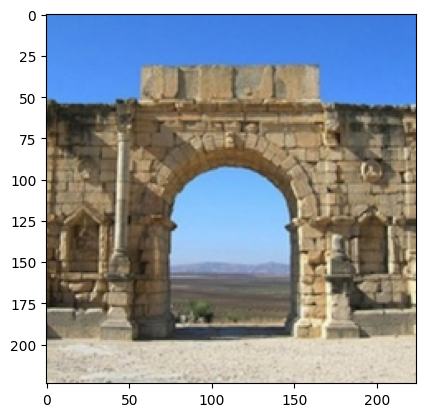

In [13]:
import matplotlib.pyplot as plt
plt.imshow(mindeye_pairs_tensor[2].permute(1, 2, 0).numpy())

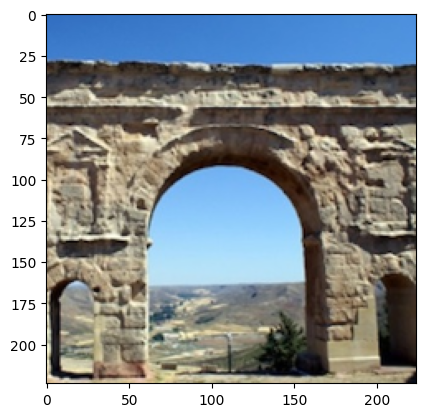

In [14]:
import matplotlib.pyplot as plt
plt.imshow(mindeye_pairs_tensor[3].permute(1, 2, 0).numpy())

In [15]:
unique_images

['pair_37_w_airplane_interior1',
 'pair_37_w_airplane_interior2',
 'pair_38_w_arch1',
 'pair_38_w_arch2',
 'pair_39_w_corridor1',
 'pair_39_w_corridor2',
 'pair_40_w_escalator1',
 'pair_40_w_escalator2',
 'pair_41_w_gym1',
 'pair_41_w_gym2',
 'pair_42_w_icerink1',
 'pair_42_w_icerink2',
 'pair_43_w_lighthouse1',
 'pair_43_w_lighthouse2',
 'pair_44_w_log_cabin1',
 'pair_44_w_log_cabin2',
 'pair_45_w_pagoda1',
 'pair_45_w_pagoda2',
 'pair_46_w_pool1',
 'pair_46_w_pool2',
 'pair_47_w_roller_coaster1',
 'pair_47_w_roller_coaster2',
 'pair_48_w_runway1',
 'pair_48_w_runway2',
 'pair_49_w_yoga_studio1',
 'pair_49_w_yoga_studio2']

In [68]:
sub = 'sub-05'

In [69]:
test_images_embeddings = torch.Tensor(mindeye_pairs_tensor)
test_vox = torch.Tensor(mindeye_pairs[sub]['vox'])
assert len(test_images_embeddings) == len(test_vox)

In [70]:
outdir_folder = '/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/'
# folder_names = {'sub-01':'sub-01_output_1771911499.2133198',
#                 'sub-02':'sub-02_output_1771391206.9882252', 
#                 'sub-04':'sub-04_output_1771391422.1811972'}
folder_names = {'sub-01':'output_sub-01_sub-01_3-session_task-mindeye_1_avgrepeats_unionmask_150epochs_1772602372.517717',
                'sub-02':'output_sub-02_sub-02_3-session_task-mindeye_2_avgrepeats_unionmask_150epochs_1772601956.315377', 
                'sub-04':'output_sub-04_sub-04_3-session_task-mindeye_4_avgrepeats_unionmask_150epochs_1772602765.0265508',
                'sub-05':'output_sub-05_sub-05_3-session_task-mindeye_5_avgrepeats_unionmask_150epochs_1772665013.0029678'}

outdir = os.path.join(outdir_folder, folder_names[sub])

In [71]:
def load_ckpt(tag,load_lr=True,load_optimizer=True,load_epoch=True,strict=True,outdir=outdir,multisubj_loading=False): 
    print(f"\n---loading {outdir}/{tag}.pth ckpt---\n")
    checkpoint = torch.load(outdir+'/last.pth', map_location='cpu')
    state_dict = checkpoint['model_state_dict']
    if multisubj_loading: # remove incompatible ridge layer that will otherwise error
        state_dict.pop('ridge.linears.0.weight',None)
    model.load_state_dict(state_dict, strict=strict)
    if load_epoch:
        globals()["epoch"] = checkpoint['epoch']
        print("Epoch",epoch)
    if load_optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if load_lr:
        lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])
    del checkpoint

In [72]:
import torch.nn as nn
### Multi-GPU config ###
from accelerate import Accelerator, DeepSpeedPlugin

local_rank = os.getenv('RANK')
if local_rank is None: 
    local_rank = 0
else:
    local_rank = int(local_rank)
print("LOCAL RANK ", local_rank)  

data_type = torch.float32 # change depending on your mixed_precision

accelerator = Accelerator(split_batches=False)

device = accelerator.device

LOCAL RANK  0


In [73]:
print("PID of this process =",os.getpid())
device = accelerator.device
print("device:",device)
world_size = accelerator.state.num_processes
distributed = not accelerator.state.distributed_type == 'NO'
num_devices = torch.cuda.device_count()
if num_devices==0 or not distributed: num_devices = 1
num_workers = num_devices
print(accelerator.state)

# set data_type to match your mixed precision (automatically set based on deepspeed config)
if accelerator.mixed_precision == "bf16":
    data_type = torch.bfloat16
elif accelerator.mixed_precision == "fp16":
    data_type = torch.float16
else:
    data_type = torch.float32

print("distributed =",distributed, "num_devices =", num_devices, "local rank =", local_rank, "world size =", world_size, "data_type =", data_type)
print = accelerator.print # only print if local_rank=0

PID of this process = 3585086
device: cuda
Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

distributed = False num_devices = 1 local rank = 0 world size = 1 data_type = torch.float32


In [74]:
from models import PriorNetwork, BrainDiffusionPrior
import utils

## USING OpenCLIP ViT-bigG ###
sys.path.append('generative_models/')
import sgm
from generative_models.sgm.modules.encoders.modules import FrozenOpenCLIPImageEmbedder
# from generative_models.sgm.models.diffusion import DiffusionEngine
# from omegaconf import OmegaConf

In [75]:
try:
    print(clip_img_embedder)
except:
    clip_img_embedder = FrozenOpenCLIPImageEmbedder(
        arch="ViT-bigG-14",
        version="laion2b_s39b_b160k",
        output_tokens=True,
        only_tokens=True,
    )
    clip_img_embedder.to(device)
clip_img_embedder.model.visual.set_grad_checkpointing(True)

clip_seq_dim = 256
clip_emb_dim = 1664

FrozenOpenCLIPImageEmbedder(
  (model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 1664, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (patch_dropout): Identity()
      (ln_pre): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): ModuleList(
          (0-47): 48 x ResidualAttentionBlock(
            (ln_1): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=1664, out_features=1664, bias=True)
            )
            (ls_1): Identity()
            (ln_2): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=1664, out_features=8192, bias=True)
              (gelu): GELU(approximate='none')
              (c_proj): Linear(in_features=8192, out_features=1664, bias=True)
            )
            (ls_2): Identity()


In [76]:
#num_voxels_list = [dic[sub]['study']['roi'].shape[-1]]
num_voxels_list = [dic[sub]['study']['roi'].shape[-1]]
n_blocks=4
hidden_dim=1024
use_prior=True
clip_scale=1.

In [77]:
model = utils.prepare_model_and_training(
    num_voxels_list=num_voxels_list,
    n_blocks=n_blocks,
    hidden_dim=hidden_dim,
    clip_emb_dim=clip_emb_dim,
    clip_seq_dim=clip_seq_dim,
    use_prior=use_prior,
    clip_scale=clip_scale,
    seed=315
)

MindEyeModule()
param counts:
7,729,152 total
7,729,152 trainable
param counts:
7,729,152 total
7,729,152 trainable
param counts:
453,360,280 total
453,360,280 trainable
param counts:
461,089,432 total
461,089,432 trainable
param counts:
259,865,216 total
259,865,200 trainable
param counts:
720,954,648 total
720,954,632 trainable


In [78]:
epoch = 0
losses, test_losses, lrs = [], [], []
best_test_loss = 1e9
torch.cuda.empty_cache()
# tf32 data type is faster than standard float32
torch.backends.cuda.matmul.allow_tf32 = True


In [79]:
load_ckpt("last",
          outdir=outdir,load_lr=False,load_optimizer=False,load_epoch=False,
          strict=True,multisubj_loading=False)
model.to(device)


---loading /scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/output_sub-05_sub-05_3-session_task-mindeye_5_avgrepeats_unionmask_150epochs_1772665013.0029678/last.pth ckpt---



MindEyeModule(
  (ridge): RidgeRegression(
    (linears): ModuleList(
      (0): Linear(in_features=7547, out_features=1024, bias=True)
    )
  )
  (backbone): BrainNetwork(
    (mixer_blocks1): ModuleList(
      (0-3): 4 x Sequential(
        (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (1): Sequential(
          (0): Linear(in_features=1024, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.15, inplace=False)
          (3): Linear(in_features=1024, out_features=1024, bias=True)
        )
      )
    )
    (mixer_blocks2): ModuleList(
      (0-3): 4 x Sequential(
        (0): LayerNorm((1,), eps=1e-05, elementwise_affine=True)
        (1): Sequential(
          (0): Linear(in_features=1, out_features=1, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.15, inplace=False)
          (3): Linear(in_features=1, out_features=1, bias=True)
        )
      )
    )
    (backbone_linear): Linear(i

In [80]:
evaluate_MST(test_vox, test_images_embeddings, mindeye_pairs[sub]['pairs'])

score: 12
total: 26
0.46153846153846156


In [ ]:
# sub-01: 0.6923076923076923
# sub-02: 0.6538461538461539
# sub-04: 0.8076923076923077
# sub-05: 0.46153846153846156

In [30]:
def evaluate_MST(vox, images, pairs):

    score = 0
    total = 0

    model.eval()
    with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type):
        for pair in pairs:
            voxel = vox[pair[0]].to(device)[None]
            voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

            imageA = images[pair[0]].to(device)[None]
            imageB = images[pair[1]].to(device)[None]

            clip_targetA = clip_img_embedder(imageA.float())
            clip_targetB = clip_img_embedder(imageB.float())

            voxel_ridge = model.ridge(voxel,0)
            backbone, clip_voxels, _ = model.backbone(voxel_ridge)

            clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
            clip_targetA_norm = nn.functional.normalize(clip_targetA.flatten(1), dim=-1)
            clip_targetB_norm = nn.functional.normalize(clip_targetB.flatten(1), dim=-1)

            voxel1 = clip_voxels_norm

            if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm):
                score += 1
            total += 1

            voxel = vox[pair[1]].to(device)[None]
            voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

            voxel_ridge = model.ridge(voxel,0)
            backbone, clip_voxels, _ = model.backbone(voxel_ridge)
            clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)

            if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm):
                score += 1
            total += 1

            #print('voxels similarity:', utils.pairwise_cosine_similarity(voxel1, clip_voxels_norm))
            #print('image/voxel similarity:', utils.pairwise_cosine_similarity(voxel1, clip_targetA_norm))
            #print('comp_image/voxel similarity:',utils.pairwise_cosine_similarity(voxel1, clip_targetB_norm))

        print('score:', score)
        print('total:', total)


    print(score/total)

In [ ]:
# sub01: 0.5769230769230769
# sub02: 0.5
# sub04: 0.46153846153846156


In [ ]:
# sub01: 0.5
# sub02: 0.5384615384615384
# sub04: 0.4230769230769231
# sub05: 0.4230769230769231


In [ ]:
# sub05: 0.6153846153846154
# sub04: 0.38461538461538464
# sub05: 0.4230769230769231
# sub04: 0.4230769230769231
# sub04: 0.5769230769230769

In [75]:
model.eval()
with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type):
    # Reset metrics for this subset
    test_fwd_percent_correct = 0
    test_bwd_percent_correct = 0

    for test_i, behav in enumerate(test_dl):
        behav = behav[0]
        loss = 0.
        image = images[behav.long().cpu()].to(device)
        voxel = vox[behav.long().cpu()]
        voxel = torch.Tensor(voxel).unsqueeze(1).to(device)
        clip_img_embedder = clip_img_embedder.to(device)
        clip_target = clip_img_embedder(image.float())

        voxel_ridge = model.ridge(voxel, 0)
        backbone, clip_voxels, blurry_image_enc_ = model.backbone(voxel_ridge)

        clip_voxels_norm = torch.nn.functional.normalize(clip_voxels, dim=-1)
        clip_target_norm = torch.nn.functional.normalize(clip_target, dim=-1)

        if clip_scale > 0:
            labels = torch.arange(len(clip_voxels_norm)).to(clip_voxels_norm.device)
            test_fwd_percent_correct += utils.topk(utils.batchwise_cosine_similarity(clip_voxels_norm, clip_target_norm), labels, k=2).item()
            test_bwd_percent_correct += utils.topk(utils.batchwise_cosine_similarity(clip_target_norm, clip_voxels_norm), labels, k=2).item()
        print(test_fwd_percent_correct)
        print(test_bwd_percent_correct)
        print({
            f"test/fwd_pct_correct": test_fwd_percent_correct / (test_i + 1),
            f"test/bwd_pct_correct": test_bwd_percent_correct / (test_i + 1),
        })

0.03846153989434242
0.03846153989434242
{'test/fwd_pct_correct': 0.03846153989434242, 'test/bwd_pct_correct': 0.03846153989434242}


In [ ]:
top_k = 5

for x in range(len(unique_images)):
    # Get top-k indices
    y = torch.topk(utils.batchwise_cosine_similarity(clip_voxels_norm, clip_target_norm)[x], k=top_k).indices.to('cpu').tolist()

    # Set up the plot with original + top_k images in one row
    fig, axs = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3))
    
    # Plot the original image
    orig_img = utils.torch_to_Image(images[x])
    axs[0].imshow(orig_img)
    axs[0].set_title("Original")
    axs[0].axis("off")

    # Plot the top-k retrieved images
    for idx, i in enumerate(y):
        pred_img = utils.torch_to_Image(images[i])
        axs[idx + 1].imshow(pred_img)
        axs[idx + 1].set_title(f"Top {idx+1}")
        axs[idx + 1].axis("off")
    
    plt.tight_layout()
    plt.show()

## randomly selected 24 images

In [ ]:
sub = 'sub-01'

In [ ]:
unique_images = set(dic[sub]['01']['trial'] + dic[sub]['02']['trial'] + dic[sub]['03']['trial'])


In [ ]:
import imageio.v2 as imageio
resize_transform = transforms.Resize((224, 224))

images = None

img_path = f'{folder_path}/{sub}_loaded_mindeye_imgs.pkl'
idx_path = f'{folder_path}/{sub}_loaded_mindeye_idxs.pkl'

if os.path.exists(img_path):
    with open(img_path, 'rb') as file:
        images = pickle.load(file)
        print('Loading image saved at: ', file)
    with open(idx_path, 'rb') as file:
        unique_images = pickle.load(file)
        print('Loading image saved at: ', file)
else:
    for img in tqdm(unique_images):

        root_dir = os.path.join(data_folder, 'stimuli')
        if 'unchosen' in img:
            image_file = f'{root_dir}/unchosen_nsd_1000_images/{img}.png'
        elif 'special' in img and 'notspecial' not in img:
            image_file = f'{root_dir}/special515/{img}.jpg'
        elif 'notspecial' in img:
            image_file = f'{root_dir}/shared1000_notspecial/{img}.png'
        elif 'pair_' and '_w_' in img:
            image_file = f'{root_dir}/MST_pairs/{img}.jpg'
        else:
            print('====ERROR: CANNOT FIND THE IMAGE WITH THE FOLLOWING PATH====')
            print(img)
            break

        if image_file and not os.path.exists(image_file):
            print('Cannot find the image at this path',image_file)
            break

        im = imageio.imread(image_file)
        im = torch.Tensor(im / 255).permute(2,0,1)
        im = resize_transform(im.unsqueeze(0))

        if images is None:
            images = im
        else:
            images = torch.vstack((images, im))

    
    print(folder_path)
    with open(img_path, 'wb') as file:
        pickle.dump(images, file)
        print('image saved at: ', file)
        
    with open(idx_path, 'wb') as file:
        pickle.dump(unique_images, file)
        print('image idx saved at: ', file)
        
print("images", images.shape)

In [ ]:
unique_images = list(unique_images)

In [145]:
test_data = {}
test_vox = dic[sub]['03']['roi']
test_trial = dic[sub]['03']['trial']
unique_test_trial = set(test_trial)
test_vox = average_repeats(test_vox, test_trial, unique_test_trial)
test_data[sub] = test_vox

img_size = images.shape[-3:]
new_shape = (len(unique_test_trial), *img_size) 
print(new_shape)

updated_test_images = torch.empty(new_shape)
for i, img in enumerate(unique_test_trial):
    img_idx = unique_images.index(img)
    updated_test_images[i] = images[img_idx, :]

(561, 3, 224, 224)


In [146]:
def find_repeated_strings(string_list):
    """
    Finds all repeated strings in a list and returns a dictionary 
    with the string as the key and a list of its indices as the value.
    Uses a set to track seen items efficiently.
    """
    # Set to quickly track which items have appeared once already
    seen_once = set()
    # Dictionary to store only the indices of items that repeat
    repeated_strings_dict = {}

    for index, string_val in enumerate(string_list):
        if string_val in repeated_strings_dict:
            # If already in the 'repeated_strings_dict', just append the new index
            repeated_strings_dict[string_val].append(index)
        elif string_val in seen_once:
            # First time seeing a repeat: move from 'seen_once' to 'repeated_strings_dict'
            repeated_strings_dict[string_val] = [string_list.index(string_val), index]
        else:
            # First time seeing the item overall
            seen_once.add(string_val)
            
    return repeated_strings_dict

def average_repeats(vox, mindeye_trial, unique_images):
    
    repeated_trial = find_repeated_strings(mindeye_trial)
    
    sorted_vox = np.zeros((len(unique_images), vox.shape[1]))
    
    # Average repeated MST images
    for i, img in enumerate(unique_images):

        if img in repeated_trial.keys(): # deal with repeated images
            # average all repeats across sessions
            curr_trial_vox = np.mean(vox[repeated_trial[img]], axis=0)
            
        elif img in mindeye_trial: # deal with once images
            idx = mindeye_trial.index(img)
            curr_trial_vox = vox[idx, :]
            
        else: # error handeling
            print(f"{img} is not in the list")
            break
        
        sorted_vox[i, :] = curr_trial_vox
    
    return sorted_vox

In [147]:
test_vox = dic[sub]['03']['roi']
test_trial = dic[sub]['03']['trial']
unique_test_trial = set(test_trial)
test_vox = average_repeats(test_vox, test_trial, unique_test_trial)
test_data[sub] = test_vox

img_size = images.shape[-3:]
new_shape = (len(unique_test_trial), *img_size) 
print(new_shape)

updated_test_images = torch.empty(new_shape)
for i, img in enumerate(unique_test_trial):
    img_idx = unique_images.index(img)
    updated_test_images[i] = images[img_idx, :]

(561, 3, 224, 224)


In [148]:
test_images = torch.Tensor(updated_test_images)
test_vox = torch.Tensor(test_vox)
assert len(test_images) == len(test_vox)

In [149]:
print('test images shape:', test_images.shape)
print('test vox shape:', test_vox.shape)

test images shape: torch.Size([561, 3, 224, 224])
test vox shape: torch.Size([561, 6108])


In [150]:
test_images_embeddings = torch.Tensor(test_images)
test_vox = torch.Tensor(test_vox)
assert len(test_images_embeddings) == len(test_vox)

In [151]:
outdir_folder = '/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/'
folder_names = {'sub-01':'sub-01_output_1771911499.2133198',
                'sub-02':'sub-02_output_1771391206.9882252', 
                'sub-04':'sub-04_output_1771391422.1811972'}
folder_names = {'sub-01':'output_sub-01_sub-01_3-session_task-mindeye_1_avgrepeats_unionmask_150epochs_1772602372.517717',
                'sub-02':'output_sub-02_sub-02_3-session_task-mindeye_2_avgrepeats_unionmask_150epochs_1772601956.315377', 
                'sub-04':'output_sub-04_sub-04_3-session_task-mindeye_4_avgrepeats_unionmask_150epochs_1772602765.0265508',
                'sub-05':'output_sub-05_sub-05_3-session_task-mindeye_5_avgrepeats_unionmask_150epochs_1772665013.0029678'}

outdir = os.path.join(outdir_folder, folder_names[sub])

In [152]:
def load_ckpt(tag,load_lr=True,load_optimizer=True,load_epoch=True,strict=True,outdir=outdir,multisubj_loading=False): 
    print(f"\n---loading {outdir}/{tag}.pth ckpt---\n")
    checkpoint = torch.load(outdir+'/last.pth', map_location='cpu')
    state_dict = checkpoint['model_state_dict']
    if multisubj_loading: # remove incompatible ridge layer that will otherwise error
        state_dict.pop('ridge.linears.0.weight',None)
    model.load_state_dict(state_dict, strict=strict)
    if load_epoch:
        globals()["epoch"] = checkpoint['epoch']
        print("Epoch",epoch)
    if load_optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if load_lr:
        lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])
    del checkpoint

In [153]:
import torch.nn as nn
### Multi-GPU config ###
from accelerate import Accelerator, DeepSpeedPlugin

local_rank = os.getenv('RANK')
if local_rank is None: 
    local_rank = 0
else:
    local_rank = int(local_rank)
print("LOCAL RANK ", local_rank)  

data_type = torch.float32 # change depending on your mixed_precision

accelerator = Accelerator(split_batches=False)

device = accelerator.device

LOCAL RANK  0


In [154]:
print("PID of this process =",os.getpid())
device = accelerator.device
print("device:",device)
world_size = accelerator.state.num_processes
distributed = not accelerator.state.distributed_type == 'NO'
num_devices = torch.cuda.device_count()
if num_devices==0 or not distributed: num_devices = 1
num_workers = num_devices
print(accelerator.state)

# set data_type to match your mixed precision (automatically set based on deepspeed config)
if accelerator.mixed_precision == "bf16":
    data_type = torch.bfloat16
elif accelerator.mixed_precision == "fp16":
    data_type = torch.float16
else:
    data_type = torch.float32

print("distributed =",distributed, "num_devices =", num_devices, "local rank =", local_rank, "world size =", world_size, "data_type =", data_type)
print = accelerator.print # only print if local_rank=0

PID of this process = 3513661
device: cuda
Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

distributed = False num_devices = 1 local rank = 0 world size = 1 data_type = torch.float32


In [155]:
from models import PriorNetwork, BrainDiffusionPrior
import utils

## USING OpenCLIP ViT-bigG ###
sys.path.append('generative_models/')
import sgm
from generative_models.sgm.modules.encoders.modules import FrozenOpenCLIPImageEmbedder
# from generative_models.sgm.models.diffusion import DiffusionEngine
# from omegaconf import OmegaConf

In [156]:
try:
    print(clip_img_embedder)
except:
    clip_img_embedder = FrozenOpenCLIPImageEmbedder(
        arch="ViT-bigG-14",
        version="laion2b_s39b_b160k",
        output_tokens=True,
        only_tokens=True,
    )
    clip_img_embedder.to(device)
clip_img_embedder.model.visual.set_grad_checkpointing(True)

clip_seq_dim = 256
clip_emb_dim = 1664

FrozenOpenCLIPImageEmbedder(
  (model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 1664, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (patch_dropout): Identity()
      (ln_pre): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): ModuleList(
          (0-47): 48 x ResidualAttentionBlock(
            (ln_1): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=1664, out_features=1664, bias=True)
            )
            (ls_1): Identity()
            (ln_2): LayerNorm((1664,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=1664, out_features=8192, bias=True)
              (gelu): GELU(approximate='none')
              (c_proj): Linear(in_features=8192, out_features=1664, bias=True)
            )
            (ls_2): Identity()


In [157]:
#num_voxels_list = [dic[sub]['study']['roi'].shape[-1]]
num_voxels_list = [dic[sub]['study']['roi'].shape[-1]]
n_blocks=4
hidden_dim=1024
use_prior=False
clip_scale=1.

model = utils.prepare_model_and_training(
    num_voxels_list=num_voxels_list,
    n_blocks=n_blocks,
    hidden_dim=hidden_dim,
    clip_emb_dim=clip_emb_dim,
    clip_seq_dim=clip_seq_dim,
    use_prior=use_prior,
    clip_scale=clip_scale
)

MindEyeModule()
param counts:
6,255,616 total
6,255,616 trainable
param counts:
6,255,616 total
6,255,616 trainable
param counts:
453,360,280 total
453,360,280 trainable
param counts:
459,615,896 total
459,615,896 trainable


In [158]:
epoch = 0
losses, test_losses, lrs = [], [], []
best_test_loss = 1e9
torch.cuda.empty_cache()
# tf32 data type is faster than standard float32
torch.backends.cuda.matmul.allow_tf32 = True


In [159]:
load_ckpt("last",
          outdir=outdir,load_lr=False,load_optimizer=False,load_epoch=False,strict=False,multisubj_loading=True)
model.to(device)


---loading /scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/output_sub-01_sub-01_3-session_task-mindeye_1_avgrepeats_unionmask_150epochs_1772602372.517717/last.pth ckpt---



MindEyeModule(
  (ridge): RidgeRegression(
    (linears): ModuleList(
      (0): Linear(in_features=6108, out_features=1024, bias=True)
    )
  )
  (backbone): BrainNetwork(
    (mixer_blocks1): ModuleList(
      (0-3): 4 x Sequential(
        (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (1): Sequential(
          (0): Linear(in_features=1024, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.15, inplace=False)
          (3): Linear(in_features=1024, out_features=1024, bias=True)
        )
      )
    )
    (mixer_blocks2): ModuleList(
      (0-3): 4 x Sequential(
        (0): LayerNorm((1,), eps=1e-05, elementwise_affine=True)
        (1): Sequential(
          (0): Linear(in_features=1, out_features=1, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.15, inplace=False)
          (3): Linear(in_features=1, out_features=1, bias=True)
        )
      )
    )
    (backbone_linear): Linear(i

In [160]:
test_data = torch.utils.data.TensorDataset(torch.tensor(range(len(test_images))))
test_dl = torch.utils.data.DataLoader(test_data, batch_size=24, shuffle=True, drop_last=True, pin_memory=True)

In [161]:
for test_i, behav in enumerate(test_dl):  
    print(test_i)
    print(behav[0])
    break

0
tensor([278, 368, 214, 527, 198, 332,  68, 480, 538, 206,  92, 541, 130, 298,
        466,  75, 247, 171, 386,  40, 427, 533, 239, 355])


In [162]:
images = test_images_embeddings
vox = test_vox

In [163]:
    fwd_percent_correct = 0.
    bwd_percent_correct = 0.
    test_fwd_percent_correct1 = 0.
    test_bwd_percent_correct1 = 0.
    test_fwd_percent_correct2 = 0.
    test_bwd_percent_correct2 = 0.
    test_fwd_percent_correct3 = 0.
    test_bwd_percent_correct3 = 0.
    test_fwd_percent_correct4 = 0.
    test_bwd_percent_correct4 = 0.
    
    recon_cossim = 0.
    test_recon_cossim = 0.
    recon_mse = 0.
    test_recon_mse = 0.

    loss_clip_total = 0.
    loss_blurry_total = 0.
    loss_blurry_cont_total = 0.
    test_loss_clip_total = 0.
    
    loss_prior_total = 0.
    test_loss_prior_total = 0.

    blurry_pixcorr = 0.
    test_blurry_pixcorr = 0. 
    
    model.eval()
    if local_rank==0:
        with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type): 
            for test_i, behav in enumerate(test_dl):  
                behav = behav[0]

                loss=0.

                if behav.ndim>1:
                    image = images[behav[:,0].long().cpu()].to(device)
                    voxel = vox[behav.long().cpu()].mean(1)
                else:
                    image = images[behav.long().cpu()].to(device)
                    voxel1 = vox[behav.long().cpu()]
                    
                voxel1 = torch.Tensor(voxel1).unsqueeze(1).to(device)

                clip_img_embedder = clip_img_embedder.to(device)
                clip_target = clip_img_embedder(image.float())
                
                voxel_ridge1 = model.ridge(voxel1,0)
                
                backbone, clip_voxels1, blurry_image_enc_ = model.backbone(voxel_ridge1)  

                if clip_scale>0:
                    clip_voxels_norm1 = nn.functional.normalize(clip_voxels1.flatten(1), dim=-1)
                    
                    clip_target_norm = nn.functional.normalize(clip_target.flatten(1), dim=-1)
                
                # for some evals, only doing a subset of the samples per batch because of computational cost
                random_samps = np.random.choice(np.arange(len(image)), size=len(image)//5, replace=False)
                
                if use_prior:
                    loss_prior, contaminated_prior_out = model.diffusion_prior(text_embed=backbone[random_samps], image_embed=clip_target[random_samps])
                    test_loss_prior_total += loss_prior.item()
                    loss_prior *= prior_scale
                    loss += loss_prior
                        
                if clip_scale>0:
                    loss_clip = utils.soft_clip_loss(
                        clip_voxels_norm1,
                        clip_target_norm,
                        temp=.006)

                    loss_clip = loss_clip * clip_scale
                    loss += loss_clip

                if clip_scale>0:
                    # forward and backward top 1 accuracy        
                    labels1 = torch.arange(len(clip_voxels_norm1)).to(clip_voxels_norm1.device) 
                    test_fwd_percent_correct1 += utils.topk(utils.batchwise_cosine_similarity(clip_voxels_norm1, clip_target_norm), labels1, k=1).item()
                    test_bwd_percent_correct1 += utils.topk(utils.batchwise_cosine_similarity(clip_target_norm, clip_voxels_norm1), labels1, k=1).item()                
                utils.check_loss(loss)                
                test_losses.append(loss.item())

            # assert (test_i+1) == 1
            print(
                "test/loss", np.mean(test_losses[-(test_i+1):]),
                "test/num_steps", len(test_losses),
                "test/test_fwd_pct_correct overall", test_fwd_percent_correct1 / (test_i + 1),
                "test/test_bwd_pct_correct overall", test_bwd_percent_correct1 / (test_i + 1),
            )


test/loss 3.6120859747347622 test/num_steps 23 test/test_fwd_pct_correct overall 0.0416666679084301 test/test_bwd_pct_correct overall 0.04891304493598316
